Nama : Jujur Dewa Pamungkas

Nim  : 250401020107

Prodi : PJJ Informatika

kelas :  IF403

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


Jumlah data: (244, 7)


,total_bill,tip,size
count,244.00,244.00,244.00
mean,19.79,3.00,2.57
std,8.90,1.38,0.95
min,3.07,1.00,1.00
25%,13.35,2.00,2.00
50%,17.80,2.90,2.00
75%,24.13,3.56,3.00
max,50.81,10.00,6.00


Hari,Rata-rata Total Bill (USD),Rata-rata Tip (USD),Jumlah Transaksi
Thur,17.68,2.77,62
Fri,17.15,2.73,19
Sat,20.44,2.99,87
Sun,21.41,3.26,76


Metrik,Nilai
Jumlah Transaksi,244.00
Rata-rata Total Bill,19.79
Median Total Bill,17.80
Total Bill Minimum,3.07
Total Bill Maksimum,50.81
Rata-rata Tip,3.00
Korelasi Total Bill dan Tip,0.68


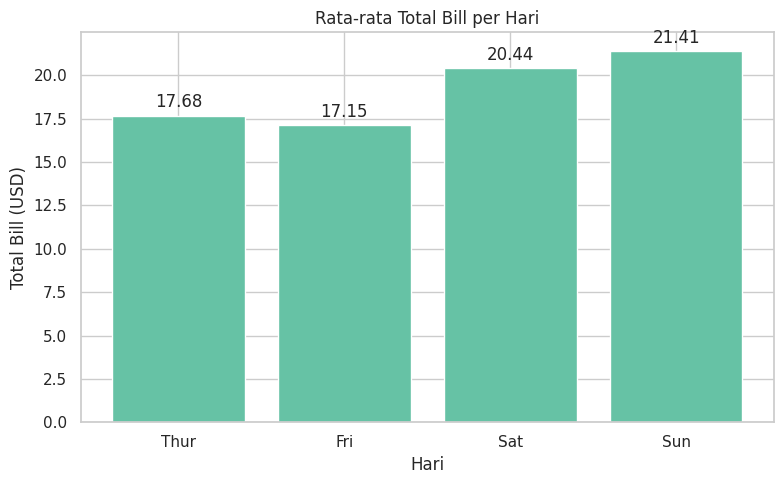

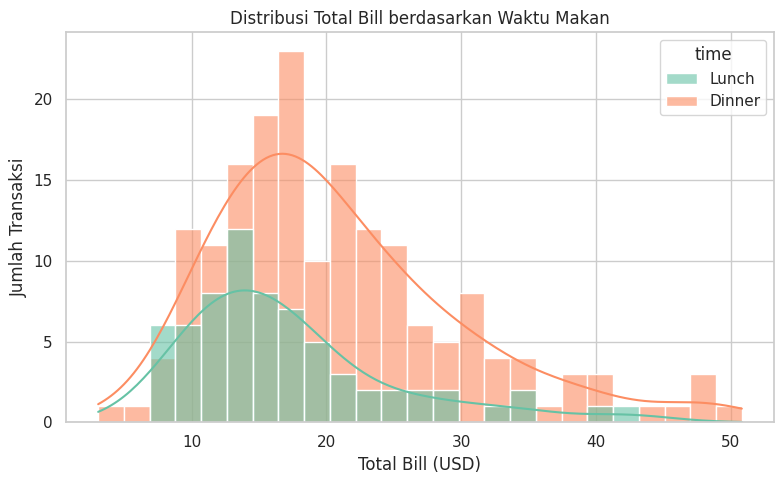

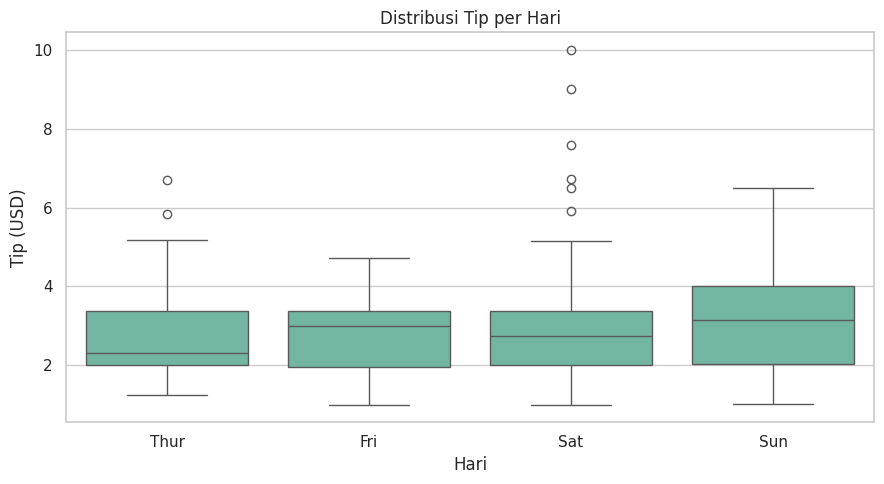

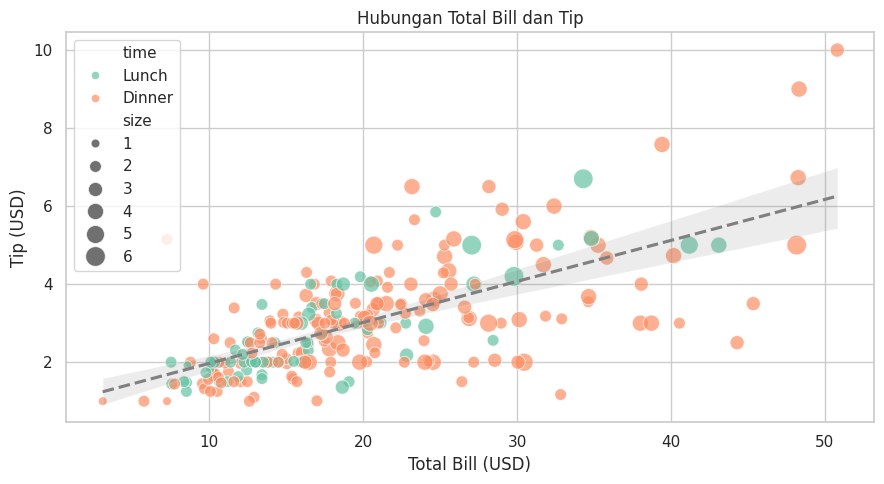

Korelasi total_bill dan tip: 0.68


,time,jumlah_transaksi,rata_rata_total_bill,rata_rata_tip,rata_rata_size
0,Lunch,68,17.17,2.73,2.41
1,Dinner,176,20.80,3.10,2.63


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='Set2')

df = sns.load_dataset('tips')

display(df.head())
print("Jumlah data:", df.shape)
display(df.describe().round(2))

# =========================
# RATA-RATA TOTAL BILL DAN TIP PER HARI
# =========================

daily_summary = df.groupby('day', observed=False).agg(
    Rata_rata_Total_Bill=('total_bill', 'mean'),
    Rata_rata_Tip=('tip', 'mean'),
    Jumlah_Transaksi=('total_bill', 'count')
).round(2).reset_index()

daily_summary.columns = [
    "Hari",
    "Rata-rata Total Bill (USD)",
    "Rata-rata Tip (USD)",
    "Jumlah Transaksi"
]

display(
    daily_summary.style
    .set_caption("Ringkasan Rata-rata Total Bill dan Tip per Hari")
    .hide(axis="index")
    .format({
        "Rata-rata Total Bill (USD)": "{:.2f}",
        "Rata-rata Tip (USD)": "{:.2f}",
        "Jumlah Transaksi": "{:.0f}"
    })
)

# =========================
# Summary Data
# =========================

summary_data = {
    "Metrik": [
        "Jumlah Transaksi",
        "Rata-rata Total Bill",
        "Median Total Bill",
        "Total Bill Minimum",
        "Total Bill Maksimum",
        "Rata-rata Tip",
        "Korelasi Total Bill dan Tip"
    ],
    "Nilai": [
        len(df),
        round(df['total_bill'].mean(), 2),
        round(df['total_bill'].median(), 2),
        round(df['total_bill'].min(), 2),
        round(df['total_bill'].max(), 2),
        round(df['tip'].mean(), 2),
        round(df['total_bill'].corr(df['tip']), 2)
    ]
}

summary_df = pd.DataFrame(summary_data)

display(
    summary_df.style
    .set_caption("Ringkasan Statistik Dataset Tips")
    .hide(axis="index")
    .format({"Nilai": "{:.2f}"})
    .set_properties(**{
        'text-align': 'left'
    })
    .set_table_styles([
        {
            'selector': 'th',
            'props': [('text-align', 'left')]
        }
    ])
)

avg_bill_by_day = df.groupby('day', observed=False)['total_bill'].mean().round(2)

plt.figure(figsize=(8, 5))
bars = plt.bar(
    avg_bill_by_day.index.astype(str),
    avg_bill_by_day.values
)

plt.title('Rata-rata Total Bill per Hari')
plt.xlabel('Hari')
plt.ylabel('Total Bill (USD)')
plt.bar_label(bars, padding=3)

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='total_bill',
    hue='time',
    kde=True,
    bins=25,
    alpha=0.6
)

plt.title('Distribusi Total Bill berdasarkan Waktu Makan')
plt.xlabel('Total Bill (USD)')
plt.ylabel('Jumlah Transaksi')

plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x='day',
    y='tip',
    order=['Thur', 'Fri', 'Sat', 'Sun']
)

plt.title('Distribusi Tip per Hari')
plt.xlabel('Hari')
plt.ylabel('Tip (USD)')

plt.tight_layout()
plt.show()
tip_summary = df.groupby('day', observed=False).agg(
    jumlah_transaksi=('tip', 'count'),
    rata_rata_tip=('tip', 'mean'),
    median_tip=('tip', 'median'),
    tip_minimum=('tip', 'min'),
    tip_maksimum=('tip', 'max')
).round(2).reset_index()

tip_summary

plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df,
    x='total_bill',
    y='tip',
    hue='time',
    size='size',
    sizes=(40, 200),
    alpha=0.7
)

sns.regplot(
    data=df,
    x='total_bill',
    y='tip',
    scatter=False,
    color='gray',
    line_kws={'linestyle': '--'}
)

plt.title('Hubungan Total Bill dan Tip')
plt.xlabel('Total Bill (USD)')
plt.ylabel('Tip (USD)')

plt.tight_layout()
plt.show()
corr_totalbill_tip = df['total_bill'].corr(df['tip']).round(2)

relation_summary = df.groupby('time', observed=False).agg(
    jumlah_transaksi=('total_bill', 'count'),
    rata_rata_total_bill=('total_bill', 'mean'),
    rata_rata_tip=('tip', 'mean'),
    rata_rata_size=('size', 'mean')
).round(2).reset_index()

print("Korelasi total_bill dan tip:", corr_totalbill_tip)
relation_summary